# Hyperparameter Selection and Validation Bias

**Docker image**: `ml4t`

**Purpose**: develop a systematic approach to hyperparameter selection for
regularized models. The notebook answers two questions:

1. How does regularization affect Ridge performance on the ETF panel? (alpha
   grid analysis)
2. How much does HPO selection bias inflate single-loop CV estimates relative
   to nested CV? (Cawley and Talbot 2010)

**Learning objectives**

- Map performance stability across a wide regularization range
- Distinguish a robust alpha plateau from a noisy landscape
- Implement nested walk-forward CV with proper inner/outer purging and embargo
- Quantify the inflation from optimizing hyperparameters and reporting on the
  same data
- Apply the 3σ overfitting diagnostic to a hyperparameter search

**Book reference**: Section 11.2 — Regularized Regression (nested CV +
selection bias).

**Prerequisites**

- Ch7 21-day forward return labels at `case_studies/etfs/labels/fwd_ret_21d.parquet`
- Ch8 ETF features at `case_studies/etfs/features/financial.parquet`
- `02_regularization_paths` (coefficient paths context for Ridge)

**Downstream**: Ch12 extends the same nested-CV machinery to gradient boosting's
higher-dimensional hyperparameter space.

## 1. Setup and Imports

In [1]:
"""Hyperparameter Selection and Validation Bias — nested CV for unbiased performance evaluation."""

import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import polars as pl
from matplotlib.colors import LinearSegmentedColormap
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from ml4t.diagnostic.splitters import WalkForwardCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from utils.paths import get_case_study_dir, get_chapter_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, ml4t_diverging

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
SEED = 42
RETRAIN = False
MAX_SYMBOLS = 0
N_SPLITS = 5
N_TRIALS = 20
CV_MAX_SPLITS = 0
CV_MAX_TRIALS = 0
ALPHA_GRID_POINTS = 23
TEST_SIZE = 200
ARTIFACT_TAG = ""

In [3]:
# Configuration
RANDOM_SEED = SEED
set_global_seeds(SEED)
N_SPLITS_EFFECTIVE = N_SPLITS if CV_MAX_SPLITS <= 0 else min(N_SPLITS, CV_MAX_SPLITS)
N_TRIALS_EFFECTIVE = N_TRIALS if CV_MAX_TRIALS <= 0 else min(N_TRIALS, CV_MAX_TRIALS)

## 2. Load ETF Features

We use the pre-computed ETF features from Chapter 8 and labels from Chapter 7.

In [4]:
# Load ETF features and labels from centralized case study store
CASE_DIR = get_case_study_dir("etfs")
FEATURES_PATH = CASE_DIR / "features" / "financial.parquet"
LABELS_PATH = CASE_DIR / "labels" / "fwd_ret_21d.parquet"

assert FEATURES_PATH.exists(), (
    f"Features not found: {FEATURES_PATH}\nRun Ch8 feature engineering first."
)
assert LABELS_PATH.exists(), f"Labels not found: {LABELS_PATH}\nRun Ch7 label engineering first."

features_df = pl.read_parquet(FEATURES_PATH).with_columns(pl.col("timestamp").cast(pl.Date))
labels_df = pl.read_parquet(LABELS_PATH).with_columns(pl.col("timestamp").cast(pl.Date))

# Join features and labels
TARGET_COL = "fwd_ret_21d"
ASSET_COL = "symbol"
dataset = features_df.join(labels_df, on=["timestamp", ASSET_COL], how="inner").drop_nulls(
    subset=[TARGET_COL]
)
dataset = dataset.sort(["timestamp", ASSET_COL])

if MAX_SYMBOLS > 0:
    assets = sorted(dataset[ASSET_COL].unique().to_list())[:MAX_SYMBOLS]
    dataset = dataset.filter(pl.col(ASSET_COL).is_in(assets))

print(f"Dataset: {len(dataset):,} rows")
print(f"Assets: {dataset[ASSET_COL].n_unique()}")
print(f"Date range: {dataset['timestamp'].min()} to {dataset['timestamp'].max()}")

Dataset: 394,233 rows
Assets: 99
Date range: 2007-01-03 to 2025-12-01


## 3. Prepare Features and Target

In [5]:
# Identify feature and target columns
meta_cols = {"timestamp", ASSET_COL}
label_cols = {c for c in dataset.columns if c.startswith("fwd_ret")}
feature_cols = [c for c in dataset.columns if c not in meta_cols and c not in label_cols]

# Prepare arrays
# Replace inf/NaN with null, then fill remaining nulls with 0
df = (
    dataset.select(feature_cols + [TARGET_COL, "timestamp", ASSET_COL])
    .with_columns(
        [
            pl.when(pl.col(c).is_nan() | pl.col(c).is_infinite())
            .then(None)
            .otherwise(pl.col(c))
            .alias(c)
            for c in feature_cols
        ]
    )
    .fill_null(0)
)
X = df.select(feature_cols).to_numpy()
y = df[TARGET_COL].to_numpy()
X = np.nan_to_num(X, nan=0.0)

# Create DataFrame with datetime index for WalkForwardCV
dates = df["timestamp"].to_list()
dates_arr = df["timestamp"].to_numpy()
symbols_arr = df[ASSET_COL].to_numpy()
df_for_cv = pd.DataFrame(X, columns=feature_cols)
df_for_cv.index = pd.DatetimeIndex(dates).tz_localize("UTC")


def cross_sectional_ic_mean(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dates: np.ndarray,
    symbols: np.ndarray,
) -> float:
    """Mean cross-sectional Spearman IC across dates in a fold."""
    pred_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
    )
    ic_clean = ic_per_date.drop_nulls("ic")
    return float(ic_clean["ic"].mean()) if ic_clean.height else float("nan")


print(f"Final dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Target: {TARGET_COL}")

Final dataset: 394233 samples, 57 features
Target: fwd_ret_21d


---
# Part A: Alpha Grid Analysis

Before optimizing hyperparameters, we should understand the **landscape** of
performance across regularization levels. This reveals:

- Is there a stable plateau where performance is robust?
- Or is performance noisy/sensitive to alpha choice?
- Should we use a single alpha or an ensemble?

This analysis informs our HPO strategy before we even run Optuna.

## 4. Define Alpha Grid and Evaluation Function

In [6]:
# Alpha grid spanning weak to strong regularization
ALPHAS = np.logspace(-2, 9, ALPHA_GRID_POINTS)  # 0.01 to 1e9
LABEL_HORIZON = 21  # 1-month forward returns

### Evaluate Alpha Grid

Walk-forward CV across the full alpha range, returning per-fold IC for each alpha.

In [7]:
def evaluate_alpha_grid(
    X: np.ndarray,
    y: np.ndarray,
    df_cv: pd.DataFrame,
    alphas: np.ndarray,
    n_splits: int,
    test_size: int,
    label_horizon: int,
) -> pd.DataFrame:
    """
    Evaluate Ridge regression across a grid of alphas for each CV fold.

    Returns DataFrame with columns: fold, alpha, ic
    """
    results = []

    cv = WalkForwardCV(
        n_splits=n_splits,
        test_size=test_size,
        label_horizon=label_horizon,
        embargo_size=10,
        expanding=True,
    )

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(df_cv)):
        if len(train_idx) < 10:
            continue

        X_train_raw, X_test_raw = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Scale inside fold
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        dates_test = dates_arr[test_idx]
        symbols_test = symbols_arr[test_idx]

        # Evaluate each alpha
        for alpha in alphas:
            model = Ridge(alpha=alpha, random_state=RANDOM_SEED)
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            ic = cross_sectional_ic_mean(y_test, pred, dates_test, symbols_test)
            ic = ic if not np.isnan(ic) else 0.0

            results.append({"fold": fold_idx + 1, "alpha": alpha, "ic": ic})

    return pd.DataFrame(results)

## 5. Run Alpha Grid Analysis

In [8]:
MODELS_DIR = get_chapter_dir(11) / "models" / "04_nested_cv_hpo"
is_reduced_run = CV_MAX_SPLITS > 0 or CV_MAX_TRIALS > 0 or ALPHA_GRID_POINTS < 23 or MAX_SYMBOLS > 0
if is_reduced_run and not ARTIFACT_TAG:
    ARTIFACT_TAG = "_fast"

GRID_PATH = MODELS_DIR / f"grid_results{ARTIFACT_TAG}.joblib"
CV_PATH = MODELS_DIR / f"cv_results{ARTIFACT_TAG}.joblib"

NEED_GRID = RETRAIN or not GRID_PATH.exists()

if not NEED_GRID:
    grid_results = joblib.load(GRID_PATH)
    cached_alphas = np.sort(grid_results["alpha"].unique())
    if (
        cached_alphas.min() > ALPHAS.min()
        or cached_alphas.max() < ALPHAS.max()
        or len(cached_alphas) < len(ALPHAS)
    ):
        print("Cached grid uses a narrower alpha range; recomputing with expanded sweep.")
        NEED_GRID = True

if NEED_GRID:
    print("Evaluating alpha grid across CV folds...")
    grid_results = evaluate_alpha_grid(
        X, y, df_for_cv, ALPHAS, N_SPLITS_EFFECTIVE, TEST_SIZE, LABEL_HORIZON
    )
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(grid_results, GRID_PATH)

# Pivot to get fold × alpha matrix
ic_matrix = grid_results.pivot(index="fold", columns="alpha", values="ic")
print(f"\nGrid shape: {ic_matrix.shape[0]} folds × {ic_matrix.shape[1]} alphas")


Grid shape: 5 folds × 23 alphas


## 6. Visualize Alpha Landscape

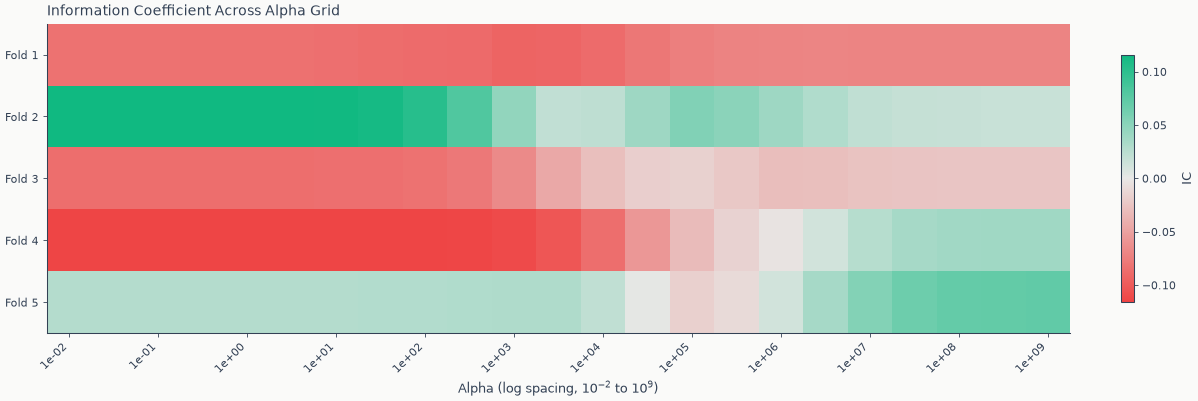

In [9]:
# Heatmap of IC across folds and alphas
# ML4T diverging scale (negative -> neutral -> positive) for the meaningful IC=0 point.
ml4t_div = LinearSegmentedColormap.from_list("ml4t_div", ml4t_diverging())
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(
    ic_matrix.values,
    aspect="auto",
    cmap=ml4t_div,
    vmin=-ic_matrix.values.max(),
    vmax=ic_matrix.values.max(),
)
# Compact scientific labels (every other tick) keep the alpha grid legible.
tick_idx = list(range(0, len(ic_matrix.columns), 2))
ax.set_xticks(tick_idx)
ax.set_xticklabels(
    [f"{ic_matrix.columns[i]:.0e}" for i in tick_idx], rotation=45, ha="right", fontsize=8
)
ax.set_yticks(range(len(ic_matrix.index)))
ax.set_yticklabels([f"Fold {i}" for i in ic_matrix.index])
ax.set_xlabel(r"Alpha (log spacing, $10^{-2}$ to $10^{9}$)")
ax.set_title("Information Coefficient Across Alpha Grid")
fig.colorbar(im, ax=ax, label="IC", shrink=0.8)
fig.show()

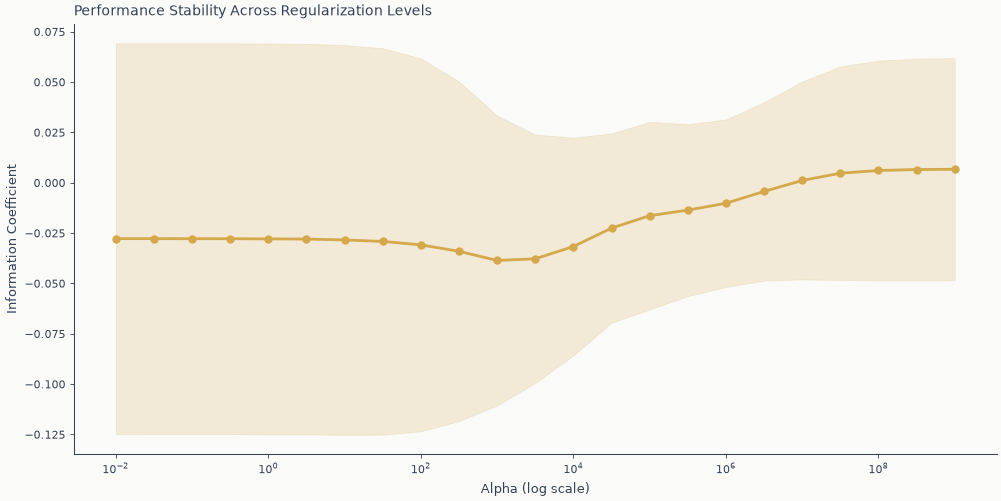

In [10]:
# Summary statistics across alphas
alpha_stats = (
    grid_results.groupby("alpha")
    .agg(
        mean_ic=("ic", "mean"),
        std_ic=("ic", "std"),
        min_ic=("ic", "min"),
        max_ic=("ic", "max"),
    )
    .reset_index()
)

# Plot mean IC with error bands
fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(
    alpha_stats["alpha"],
    alpha_stats["mean_ic"] - alpha_stats["std_ic"],
    alpha_stats["mean_ic"] + alpha_stats["std_ic"],
    alpha=0.2,
    color=COLORS["amber"],
)
ax.semilogx(
    alpha_stats["alpha"],
    alpha_stats["mean_ic"],
    "o-",
    color=COLORS["amber"],
    lw=2,
    markersize=6,
)
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("Information Coefficient")
ax.set_title("Performance Stability Across Regularization Levels")
fig.show()

## 7. Stability Analysis

In [11]:
# Compute coefficient of variation (CV) for each alpha
alpha_stats["cv"] = alpha_stats["std_ic"] / alpha_stats["mean_ic"].abs()

# Find the most stable region
best_alpha_idx = alpha_stats["mean_ic"].idxmax()
best_alpha = alpha_stats.loc[best_alpha_idx, "alpha"]
best_ic = alpha_stats.loc[best_alpha_idx, "mean_ic"]
best_std = alpha_stats.loc[best_alpha_idx, "std_ic"]

# Find stable plateau (alphas within 90% of best performance)
threshold = best_ic * 0.9 if best_ic > 0 else best_ic * 1.1
stable_alphas = alpha_stats[alpha_stats["mean_ic"] >= threshold]["alpha"]

# Assess stability
overall_cv = alpha_stats["cv"].median()
if overall_cv < 0.5:
    stability_label = "stable"
elif overall_cv < 1.0:
    stability_label = "moderate"
else:
    stability_label = "unstable"

In [12]:
stability_df = pl.DataFrame(
    {
        "Metric": [
            "Best alpha",
            "Mean IC",
            "Std IC",
            "Plateau size",
            "Plateau range",
            "Median CV",
            "Stability",
        ],
        "Value": [
            f"{best_alpha:.3f}",
            f"{best_ic:.4f}",
            f"{best_std:.4f}",
            f"{len(stable_alphas)} alphas",
            f"[{stable_alphas.min():.3f}, {stable_alphas.max():.3f}]",
            f"{overall_cv:.2f}",
            stability_label,
        ],
    }
)
stability_df

Metric,Value
str,str
"""Best alpha""","""1000000000.000"""
"""Mean IC""","""0.0067"""
"""Std IC""","""0.0552"""
"""Plateau size""","""3 alphas"""
"""Plateau range""","""[100000000.000, 1000000000.000]"""
"""Median CV""","""3.48"""
"""Stability""","""unstable"""


**Interpretation**: the empirical landscape on this dataset is dominated by
noise rather than signal. Mean IC is **negative** across most of the range
(worst around $\alpha \approx 10^3$ at $-0.039$), recovers monotonically as
regularization tightens, and only crosses zero at $\alpha \gtrsim 10^7$ to
reach a noisy peak of $\approx +0.007$ at $\alpha = 10^9$. The IC landscape
is unstable: median coefficient of variation across alphas is 3.48 — fold-level
IC swings by ±0.05–0.10 standard deviations, an order of magnitude larger
than any mean IC at any alpha.

Two consequences for Part B:

- The "best" alpha at $10^9$ is essentially indistinguishable from the
  plateau at $10^8$. The stable region is real but extremely tight at the
  top of the search range.
- With per-fold std of 0.05+ and mean IC of 0.007, the selection problem in
  single-loop CV has a lot of noise to chase. We should expect single-loop
  CV to find spuriously high alphas in some folds and quote the cherry-picked
  number as the model's "performance."

---
# Part B: Nested vs Single-Loop Cross-Validation

Now that we understand the alpha landscape, we address the **measurement problem**:
when we select hyperparameters and evaluate on the same data, we get optimistic
estimates due to selection bias.

**Key insight**: Single-loop CV (select best alpha, report that performance)
overestimates because we're measuring "how well did we fit the test set during HPO"
rather than "how well will we generalize."

## 8. Single-Loop CV (BIASED)

This approach performs HPO and evaluation on the same data splits.
The selected hyperparameters are optimized for the test set, leading to
overly optimistic results.

In [13]:
def _make_single_loop_objective(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    dates_test: np.ndarray,
    symbols_test: np.ndarray,
):
    """Create objective function that optimizes on test set (biased!)."""

    def objective(trial):
        alpha = trial.suggest_float("alpha", 0.01, 1e9, log=True)
        model = Ridge(alpha=alpha, random_state=RANDOM_SEED)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        ic = cross_sectional_ic_mean(y_test, pred, dates_test, symbols_test)
        return ic if not np.isnan(ic) else -1.0

    return objective

### Single-Loop CV Runner

Runs HPO and evaluation on the same data splits — the biased baseline.

In [14]:
def single_loop_cv(
    X: np.ndarray,
    y: np.ndarray,
    df_cv: pd.DataFrame,
    n_splits: int = 5,
    n_trials: int = 15,
    label_horizon: int = 21,
    test_size: int = 200,
) -> dict:
    """
    Single-loop CV: HPO and evaluation on same splits (BIASED).

    This is the WRONG way - hyperparameters are selected based on
    the same test set used for final evaluation.
    """
    results = {"ic": [], "best_alpha": []}

    cv = WalkForwardCV(
        n_splits=n_splits,
        test_size=test_size,
        label_horizon=label_horizon,
        embargo_size=10,
        expanding=True,
    )

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(df_cv)):
        if len(train_idx) < 10:
            continue

        X_train_raw, X_test_raw = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        dates_test = dates_arr[test_idx]
        symbols_test = symbols_arr[test_idx]

        # Scale inside fold
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        # HPO on test set (this is the bias!)
        objective = _make_single_loop_objective(
            X_train, y_train, X_test, y_test, dates_test, symbols_test
        )
        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        )
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

        # Evaluate with best params on SAME test set
        best_alpha = study.best_params["alpha"]
        model = Ridge(alpha=best_alpha, random_state=RANDOM_SEED)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        ic = cross_sectional_ic_mean(y_test, pred, dates_test, symbols_test)

        results["ic"].append(ic if not np.isnan(ic) else 0.0)
        results["best_alpha"].append(best_alpha)

    return results

## 9. Nested CV (UNBIASED)

This approach uses an **inner loop** for HPO and **outer loop** for evaluation.
The test set is never seen during hyperparameter selection.

**Both loops use WalkForwardCV** to maintain proper temporal structure
with purging and embargo.

In [15]:
def _make_nested_objective(
    X_outer_train: np.ndarray,
    y_outer_train: np.ndarray,
    dates_outer_train: np.ndarray,
    symbols_outer_train: np.ndarray,
    df_inner: pd.DataFrame,
    n_inner: int,
    label_horizon: int,
):
    """
    Create objective function for nested CV inner loop.

    Uses WalkForwardCV for inner loop to maintain proper temporal
    structure with purging and embargo.
    """
    # Inner CV on outer training data only
    inner_cv = WalkForwardCV(
        n_splits=n_inner,
        test_size=max(50, len(df_inner) // (n_inner + 2)),  # Adaptive test size
        label_horizon=label_horizon,
        embargo_size=label_horizon,  # Inner embargo must also respect label horizon
        expanding=True,
    )

    def objective(trial):
        alpha = trial.suggest_float("alpha", 0.01, 1e9, log=True)
        inner_scores = []

        for inner_train_idx, inner_val_idx in inner_cv.split(df_inner):
            if len(inner_train_idx) < 10:
                continue

            X_inner_train = X_outer_train[inner_train_idx]
            X_inner_val = X_outer_train[inner_val_idx]
            y_inner_train = y_outer_train[inner_train_idx]
            y_inner_val = y_outer_train[inner_val_idx]
            dates_inner_val = dates_outer_train[inner_val_idx]
            symbols_inner_val = symbols_outer_train[inner_val_idx]

            # Scale inside inner fold
            inner_scaler = StandardScaler()
            X_inner_train_scaled = inner_scaler.fit_transform(X_inner_train)
            X_inner_val_scaled = inner_scaler.transform(X_inner_val)

            model = Ridge(alpha=alpha, random_state=RANDOM_SEED)
            model.fit(X_inner_train_scaled, y_inner_train)
            pred = model.predict(X_inner_val_scaled)
            ic = cross_sectional_ic_mean(y_inner_val, pred, dates_inner_val, symbols_inner_val)
            if not np.isnan(ic):
                inner_scores.append(ic)

        return np.mean(inner_scores) if inner_scores else -1.0

    return objective

### Nested CV Runner

Uses an inner WalkForwardCV loop for HPO, keeping the outer test set
completely hidden from hyperparameter selection.

In [16]:
def nested_cv(
    X: np.ndarray,
    y: np.ndarray,
    df_cv: pd.DataFrame,
    n_outer: int = 5,
    n_inner: int = 3,
    n_trials: int = 15,
    label_horizon: int = 21,
    test_size: int = 200,
) -> dict:
    """
    Nested CV: HPO isolated from evaluation (UNBIASED).

    Outer loop: WalkForwardCV for temporal validation
    Inner loop: WalkForwardCV for HPO (within training data only)

    This is the CORRECT approach - hyperparameters are selected using only
    training data, and final evaluation is on truly held-out test data.
    """
    results = {"ic": [], "best_alpha": []}

    outer_cv = WalkForwardCV(
        n_splits=n_outer,
        test_size=test_size,
        label_horizon=label_horizon,
        embargo_size=10,
        expanding=True,
    )

    for fold_idx, (outer_train_idx, outer_test_idx) in enumerate(outer_cv.split(df_cv)):
        if len(outer_train_idx) < 10:
            continue

        X_outer_train_raw = X[outer_train_idx]
        X_outer_test_raw = X[outer_test_idx]
        y_outer_train = y[outer_train_idx]
        y_outer_test = y[outer_test_idx]
        dates_outer_train = dates_arr[outer_train_idx]
        symbols_outer_train = symbols_arr[outer_train_idx]
        dates_outer_test = dates_arr[outer_test_idx]
        symbols_outer_test = symbols_arr[outer_test_idx]

        # Create inner DataFrame for WalkForwardCV
        df_inner = df_cv.iloc[outer_train_idx].copy()

        # Inner loop: HPO on outer training data ONLY
        objective = _make_nested_objective(
            X_outer_train_raw,
            y_outer_train,
            dates_outer_train,
            symbols_outer_train,
            df_inner,
            n_inner,
            label_horizon,
        )

        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        )
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

        # Outer evaluation with best params (UNBIASED)
        best_alpha = study.best_params["alpha"]

        # Scale outer fold for final evaluation
        outer_scaler = StandardScaler()
        X_outer_train = outer_scaler.fit_transform(X_outer_train_raw)
        X_outer_test = outer_scaler.transform(X_outer_test_raw)

        model = Ridge(alpha=best_alpha, random_state=RANDOM_SEED)
        model.fit(X_outer_train, y_outer_train)
        pred = model.predict(X_outer_test)
        ic = cross_sectional_ic_mean(y_outer_test, pred, dates_outer_test, symbols_outer_test)

        results["ic"].append(ic if not np.isnan(ic) else 0.0)
        results["best_alpha"].append(best_alpha)

    return results

## 10. Run Comparison

In [17]:
# Inner loop folds for nested CV
N_INNER = 3

NEED_CV = RETRAIN or not CV_PATH.exists()

if NEED_CV:
    print("=" * 60)
    print("Running Single-Loop CV (BIASED)...")
    print("=" * 60)
    single_results = single_loop_cv(
        X,
        y,
        df_for_cv,
        n_splits=N_SPLITS_EFFECTIVE,
        n_trials=N_TRIALS_EFFECTIVE,
        label_horizon=LABEL_HORIZON,
        test_size=TEST_SIZE,
    )

    print("\n" + "=" * 60)
    print("Running Nested CV (UNBIASED)...")
    print("=" * 60)
    nested_results = nested_cv(
        X,
        y,
        df_for_cv,
        n_outer=N_SPLITS_EFFECTIVE,
        n_inner=N_INNER,
        n_trials=N_TRIALS_EFFECTIVE,
        label_horizon=LABEL_HORIZON,
        test_size=TEST_SIZE,
    )

    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump({"single_results": single_results, "nested_results": nested_results}, CV_PATH)
    print(f"Saved results to {CV_PATH}")

### Load Cached Results

If CV results are already cached, load them and verify completeness.

In [18]:
if not NEED_CV:
    _cached = joblib.load(CV_PATH)
    single_results = _cached["single_results"]
    nested_results = _cached["nested_results"]
    del _cached
    if (
        len(single_results["ic"]) < N_SPLITS_EFFECTIVE
        or len(nested_results["ic"]) < N_SPLITS_EFFECTIVE
    ):
        print("Cached CV results appear incomplete; recomputing.")
        single_results = single_loop_cv(
            X,
            y,
            df_for_cv,
            n_splits=N_SPLITS_EFFECTIVE,
            n_trials=N_TRIALS_EFFECTIVE,
            label_horizon=LABEL_HORIZON,
            test_size=TEST_SIZE,
        )
        nested_results = nested_cv(
            X,
            y,
            df_for_cv,
            n_outer=N_SPLITS_EFFECTIVE,
            n_inner=N_INNER,
            n_trials=N_TRIALS_EFFECTIVE,
            label_horizon=LABEL_HORIZON,
            test_size=TEST_SIZE,
        )
        MODELS_DIR.mkdir(parents=True, exist_ok=True)
        joblib.dump({"single_results": single_results, "nested_results": nested_results}, CV_PATH)

## 11. Results Analysis

In [19]:
single_mean_ic = np.mean(single_results["ic"])
single_std_ic = np.std(single_results["ic"])
nested_mean_ic = np.mean(nested_results["ic"])
nested_std_ic = np.std(nested_results["ic"])

# Calculate inflation
if nested_mean_ic != 0:
    inflation_pct = (single_mean_ic - nested_mean_ic) / abs(nested_mean_ic) * 100
else:
    inflation_pct = 0.0

comparison_df = pl.DataFrame(
    {
        "Method": ["Single-Loop (Biased)", "Nested (Unbiased)", "Inflation"],
        "Mean IC": [f"{single_mean_ic:.4f}", f"{nested_mean_ic:.4f}", f"{inflation_pct:+.1f}%"],
        "Std IC": [f"{single_std_ic:.4f}", f"{nested_std_ic:.4f}", ""],
        "Alpha Range": [
            f"[{min(single_results['best_alpha']):.2f}, {max(single_results['best_alpha']):.2f}]",
            f"[{min(nested_results['best_alpha']):.2f}, {max(nested_results['best_alpha']):.2f}]",
            "",
        ],
    }
)
comparison_df

Method,Mean IC,Std IC,Alpha Range
str,str,str,str
"""Single-Loop (Biased)""","""0.0282""","""0.0651""","""[0.04, 944154723.35]"""
"""Nested (Unbiased)""","""-0.0315""","""0.0815""","""[131.81, 131.81]"""
"""Inflation""","""+189.6%""","""""",""""""


**Interpretation**: the headline number is not "189.6% inflation" but the
sign flip. Single-loop CV reports a positive mean IC of $+0.028$; nested CV
returns a **negative** mean IC of $-0.031$ on identical splits. Once HPO is
isolated from evaluation, the Ridge model on these features shows **no
genuine out-of-sample directional skill at the 21-day horizon** — the
single-loop result was selection bias chasing noise.

The alpha selections corroborate this. Single-loop CV picks alphas that span
nine orders of magnitude across folds ($[0.04,\\ 9.4 \\times 10^8]$) — TPE
happily lands wherever the test fold's noise happens to peak. Nested CV
converges to **the same alpha ($\\approx 132$) on every outer fold**, because
the inner-CV objective averaged over inner walk-forward folds is essentially
flat over many decades of $\\alpha$, and the TPE sampler with a fixed seed
settles in the same place. Stable selection on noise is exactly what we
expect from a well-behaved nested protocol when the underlying signal is
weak.

### Validation Overfitting Diagnostic (3σ Heuristic)

The text proposes a concrete diagnostic: if the best configuration's IC exceeds the
median by more than 3× the inter-configuration standard deviation, the search is
likely overfitting to validation noise. We apply this to the alpha grid from Part A,
where each alpha's mean IC across folds serves as a "trial" value.

In [20]:
trial_ics = alpha_stats["mean_ic"].values
best_trial_ic = trial_ics.max()
median_trial_ic = np.median(trial_ics)
std_trial_ic = np.std(trial_ics)

gap_sigma = (best_trial_ic - median_trial_ic) / std_trial_ic if std_trial_ic > 0 else 0.0
overfitting_flag = "WARNING: likely overfitting" if gap_sigma > 3.0 else "OK"

diagnostic_df = pl.DataFrame(
    {
        "Metric": ["Best IC", "Median IC", "Std IC", "Gap (σ)", "Overfit flag"],
        "Value": [
            f"{best_trial_ic:.4f}",
            f"{median_trial_ic:.4f}",
            f"{std_trial_ic:.4f}",
            f"{gap_sigma:.1f}σ",
            overfitting_flag,
        ],
    }
)
diagnostic_df

Metric,Value
str,str
"""Best IC""","""0.0067"""
"""Median IC""","""-0.0278"""
"""Std IC""","""0.0150"""
"""Gap (σ)""","""2.3σ"""
"""Overfit flag""","""OK"""


The gap of $\approx 2.3\sigma$ falls below the 3σ threshold, which the
heuristic flags as **OK** — the best mean IC is not an outlier among the
23 alpha trials. Note that this diagnostic is testing a different question
from the stability classification above. Stability looks at fold-level dispersion
*within* an alpha (unstable here, because the IC noise floor is ±0.05);
the 3σ heuristic looks at dispersion *across* alphas (OK, because the
alpha-by-alpha mean is itself a smooth function). Both are simultaneously
true on this dataset: the cross-alpha trajectory is well-behaved, but the
fold-to-fold IC at any given alpha is dominated by noise. That combination
is precisely why nested CV returns negative IC — there is no signal to
overfit, only noise to absorb.

## 12. Visualization

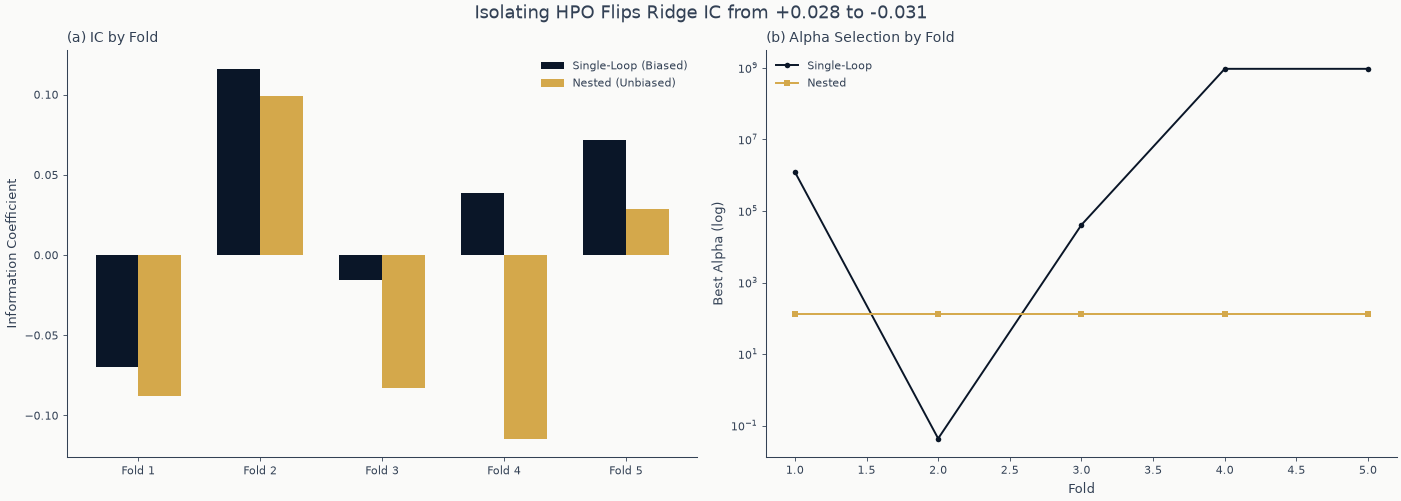

In [21]:
folds = list(range(1, len(single_results["ic"]) + 1))
x = np.arange(len(folds))
bar_w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) IC comparison
axes[0].bar(
    x - bar_w / 2, single_results["ic"], bar_w, label="Single-Loop (Biased)", color=COLORS["blue"]
)
axes[0].bar(
    x + bar_w / 2, nested_results["ic"], bar_w, label="Nested (Unbiased)", color=COLORS["amber"]
)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"Fold {f}" for f in folds])
axes[0].set_ylabel("Information Coefficient")
axes[0].set_title("(a) IC by Fold")
axes[0].legend(frameon=False)

# (b) Alpha selection
axes[1].semilogy(
    folds, single_results["best_alpha"], "o-", color=COLORS["blue"], label="Single-Loop"
)
axes[1].semilogy(folds, nested_results["best_alpha"], "s-", color=COLORS["amber"], label="Nested")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Best Alpha (log)")
axes[1].set_title("(b) Alpha Selection by Fold")
axes[1].legend(frameon=False)

fig.suptitle(
    f"Isolating HPO Flips Ridge IC from {single_mean_ic:+.3f} to {nested_mean_ic:+.3f}",
    fontsize=13,
)
fig.show()

## 13. Key Takeaways

1. **Sign-flip, not just inflation.** Single-loop CV: $+0.028$. Nested CV:
   $-0.031$. The honest unbiased estimate of the Ridge model's IC on 21-day
   ETF returns is *negative* — there is no genuine directional skill once
   HPO is isolated from evaluation. The "+189.6% inflation" headline is
   arithmetically correct but obscures the substantive result: the
   single-loop number was selection bias chasing fold-level noise.

2. **Selection-bias mechanics.** Single-loop CV chose alphas spanning nine
   orders of magnitude across folds ($[0.04, 9.4 \times 10^8]$); nested CV
   converged to a single alpha ($\approx 132$) on every outer fold. The
   dramatic narrowing is the protocol working as intended: inner-CV averaging
   refuses to reward fold-specific noise.

3. **Two stability diagnostics, both useful.** The fold-level coefficient of
   variation ($3.48$) flagged the IC landscape as unstable — fold-to-fold
   dispersion dwarfs the mean. The cross-alpha 3σ gap ($2.3\sigma$) reported
   OK — the best mean IC is not an outlier among the 23 alphas. The
   combination diagnoses a noise-dominated landscape, exactly the conditions
   under which selection bias is largest.

4. **Pre-HPO grid analysis is cheap and informative.** Sweeping a wide alpha
   grid before launching expensive nested HPO reveals whether a signal even
   exists. Here the grid's negative-mean trajectory across most of the range
   is itself a warning sign that the Ridge model is unlikely to deliver
   out-of-sample skill.

5. **Nested walk-forward is non-negotiable for honest performance reports.**
   Inner and outer loops both need purging and embargo to respect the
   label horizon.

**Reference**: Cawley and Talbot (2010) document the same bias mechanism
across multiple datasets and model classes.

In [22]:
print("Hyperparameter selection analysis complete")
print(
    f"  Alpha grid: {len(ALPHAS)} levels evaluated, mean IC range "
    f"{alpha_stats['mean_ic'].min():.4f} to {alpha_stats['mean_ic'].max():.4f}"
)
print(f"  Single-loop mean IC: {single_mean_ic:+.4f}  |  Nested mean IC: {nested_mean_ic:+.4f}")
print(f"  HPO inflation:       {inflation_pct:+.1f}%   |  Sign-flip across protocols")
print(f"  Stability label:     {stability_label}   |  Cross-alpha gap: {gap_sigma:.1f}σ")

Hyperparameter selection analysis complete
  Alpha grid: 23 levels evaluated, mean IC range -0.0386 to 0.0067
  Single-loop mean IC: +0.0282  |  Nested mean IC: -0.0315
  HPO inflation:       +189.6%   |  Sign-flip across protocols
  Stability label:     unstable   |  Cross-alpha gap: 2.3σ
